In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
import math  
import sklearn.metrics 
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Resumen

1. Crear la matriz de usuarios/películas
2. Normalización de los datos
3. Crear la matriz de similitud
4. KN-Neighbours
5. Mejor K y distancia para KN-Neighbours
6. Accuracy Promedio
7. Predicciones

## 1. Crear la matriz usuarios/películas

In [2]:
df = pd.read_csv("BBDD_100K/ratings.csv")
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
indice=list(df['userId'].unique())
columnas=list(df['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
 
escasez=pd.pivot_table(data=df,values='rating',index='userId',columns='movieId')
escasez.head(10)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,3.0,5.0,4.0,4.0,3.0,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Normalización de los datos

1. **Crear una copia de la matriz:** La función primero crea una copia de la matriz original de calificaciones para evitar modificar los datos originales durante el proceso de normalización.
2. **Normalización individual por usuario:**

Para cada usuario, seleccionamos solo las calificaciones que no son NaN (es decir, las películas que el usuario ha calificado). Esto asegura que solo trabajamos con datos válidos, y los valores NaN (calificaciones ausentes) no afectan el cálculo. \
Usamos StandardScaler para transformar las calificaciones del usuario. StandardScaler ajusta las calificaciones para que tengan una media de 0 y una desviación estándar de 1.\

*Esto tiene dos beneficios:* \
Centrado en 0: Las calificaciones se centran alrededor de 0, eliminando el sesgo de usuarios que tienden a calificar de manera consistentemente alta o baja.\
Ajuste de variabilidad: La desviación estándar se ajusta a 1, lo que permite comparar las calificaciones de usuarios con diferentes patrones de calificación en una escala uniforme.\

3. **Mantener NaN donde no hay calificaciones:** Después de normalizar las calificaciones de cada usuario, colocamos los valores normalizados en sus posiciones originales en la matriz. Los valores NaN permanecen sin alterarse, conservando así la estructura de la matriz original.

4. **Reemplazo de NaN por 0:** Finalmente, los valores NaN en la matriz normalizada se reemplazan con 0. Esto es importante para algoritmos de aprendizaje automático, ya que evita la presencia de valores NaN en la matriz final y permite trabajar con una matriz completa.

In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def normalizar_datos(matriz_escasez):
    # Creamos una copia de la matriz para evitar modificar el original
    matriz_escasez_copy = matriz_escasez.copy()
    
    # Inicializamos StandardScaler sin centrado en 0 debido a NaNs
    scaler = StandardScaler(with_mean=True, with_std=True)
    
    # Aplicamos la normalización solo en las columnas que tienen datos no NaN
    for user_id in matriz_escasez_copy.index:
        # Seleccionamos las calificaciones del usuario (excluyendo NaNs)
        user_ratings = matriz_escasez_copy.loc[user_id].dropna()
        if not user_ratings.empty:
            # Normalizamos las calificaciones de este usuario
            normalized_ratings = scaler.fit_transform(user_ratings.values.reshape(-1, 1)).flatten()
            # Colocamos los valores normalizados en la matriz original, manteniendo NaNs donde no hay calificaciones
            matriz_escasez_copy.loc[user_id, user_ratings.index] = normalized_ratings
    
    # Llenamos los NaNs con 0
    matriz_escasez_copy = matriz_escasez_copy.fillna(0)
    return matriz_escasez_copy



In [5]:
matriz_normalizada = normalizar_datos(escasez)
matriz_normalizada.head(20)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.458937,0.000000,-0.458937,0.000000,0.000000,-0.458937,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.371391,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.596225,1.773677,-0.581226,1.773677,0.596225,0.596225,-0.581226,0.0,-0.581226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.958138,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.000000,0.442374,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.636784,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


También es necesario reescalar la predicción que se ha hecho, por tanto aplicamos el cálculo a la inversa, y además hacemos un .clip() para que las calificaciones no sean menores a 0.5 o mayores de 5

In [6]:
def reescalar_predicciones(predicciones_normalizadas, matriz_escasez_original, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar de cada usuario ignorando los NaNs originales
    medias_usuarios = matriz_escasez_original.mean(axis=1, skipna=True)
    desviaciones_usuarios = matriz_escasez_original.std(axis=1, skipna=True)
    
    # Aplicamos la transformación inversa sólo donde había datos originales
    predicciones_reescaladas = predicciones_normalizadas.mul(desviaciones_usuarios, axis=0).add(medias_usuarios, axis=0)
    predicciones_reescaladas = predicciones_reescaladas.where(~matriz_escasez_original.isna(), np.nan)
    predicciones_reescaladas = predicciones_reescaladas.round()
    predicciones_reescaladas = predicciones_reescaladas.clip(lower=min_rating, upper=max_rating)
    
    return predicciones_reescaladas



Como se puede ver a continuacion la matriz obtenida es exactamente igual que la principal

In [7]:
predicciones_reescaladas = reescalar_predicciones(matriz_normalizada, escasez)
predicciones_reescaladas.head(20)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,3.0,5.0,4.0,4.0,3.0,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Crear la matriz de similitud

1. Primero separaré al usuario para predecir sus calificaciones, en nuestro caso lo haremos con el usuario número 3
2. Después seleccionaré la película que quiero predecir (en este caso y gracias al EDA utilizaré la película con mas valoraciones, la cual es Forrest Gump, con el id nº356)
3. Finalmente crearé el conjunto de usuarios que vieron esa película en específico 

In [8]:
id_usuario = 3
usuario_objetivo = matriz_normalizada.iloc[[id_usuario]]
print("Usuario Objetivo:")
usuario_objetivo.head()

Usuario Objetivo:


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
id_pelicula = 356
pelicula_objetivo = matriz_normalizada.drop( id_pelicula , axis =1)
print("Película Objetivo:")
pelicula_objetivo.head()

Película Objetivo:


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.458937,0.0,-0.458937,0.0,0.0,-0.458937,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.371391,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
usuarios_que_vieron_la_pelicula_con_nulls = matriz_normalizada[356]  # Selecciono todas las filas respecto a la película en cuestión
usuarios_que_vieron_la_pelicula = matriz_normalizada[usuarios_que_vieron_la_pelicula_con_nulls != 0] # Seleccionamos solo las filas con valores diferentes a 0, de entre los que vieron esa película
#Muestra de los usuarios que vieron la película


print("Shape de usuarios_que_vieron_la_pelicula_con_nulls:", usuarios_que_vieron_la_pelicula_con_nulls.shape)
print("Shape de usuarios_que_vieron_la_pelicula:", usuarios_que_vieron_la_pelicula.shape)
usuarios_que_vieron_la_pelicula[356].head(20)

Shape de usuarios_que_vieron_la_pelicula_con_nulls: (610,)
Shape de usuarios_que_vieron_la_pelicula: (329, 9724)


userId
1    -0.458937
6     1.773677
7     1.335436
8    -0.597205
10    0.189014
11    1.315437
14    0.595067
15    1.374295
16   -0.408741
17    1.562011
18    1.215978
19   -0.655482
21    1.236300
22    1.580014
24    1.581512
26   -0.390434
27    1.370797
28    1.235465
29    0.525366
33    1.167401
Name: 356, dtype: float64

Crear bbdd con los usuarios que han visto esa peli

## 4. K-NNeighbours

 algoritmo de KNN lo utilizaré con la libreria sklearn, la cual nos proporciona el uso de diferentes distancias, tales como: minkowski,manhattan , euclídea, jaccard, chebyshev, coseno... Lo que haré en esta sección es aplicar KNN y comparar las diferentes distáncias para evaluar cual es la mejor

 1. Distancia Minkowski
 2. Distancia Manhattan
 3. Distancia Eucídeana
 4. Distancia Jaccard
 5. Distancia Chebyshev
 6. Distancia Coseno

 Recordar que el resultado obtenido por parte del KNN está normalizado, por tanto hay que reescalarlo para poder ver cual sería en realidad

In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial import distance_matrix
from scipy.spatial.distance import euclidean, pdist, squareform
from sklearn.model_selection import GridSearchCV, cross_val_score

Para cuadrar las dimensiones

In [12]:
usuarios_que_vieron_la_pelicula_con_nulls = usuarios_que_vieron_la_pelicula_con_nulls.loc[usuarios_que_vieron_la_pelicula.index]

In [13]:
min_rating = 0.5
max_rating = 5.0

def reescalar_prediccion_individual(prediccion_normalizada, id_usuario, matriz_escasez_original, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_escasez_original.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_escasez_original.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        # Clipping para mantener la predicción dentro del rango
        prediccion_reescalada = min(max(prediccion_reescalada, min_rating), max_rating)
    else:
        # Si el usuario no tiene suficientes datos para calcular media y desviación, devolvemos NaN
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

Similitud mediante distancia de minkowski

La p de la distancia Minkowski la hemos de poner a 3 o superior, a mayor cambio mayores oscilaciones tendrá la predicción, debido al énfasis que se le pone al cambio brusco de distancias. Esto lo hago ya que si no pongo p=3, por defecto se utiliza p=2, que es la que usa la distancia euclideana y por tanto darían exactamente lo mismo

In [14]:
usuario_minkowski = KNeighborsRegressor(metric='minkowski', p=3, n_neighbors=20)
usuario_minkowski.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_minkowski = usuario_minkowski.predict(usuario_objetivo)
print("Predicción normalizada:", prediccion_usuario_minkowski)
prediccion_reescalada = reescalar_prediccion_individual(prediccion_usuario_minkowski[0], id_usuario, escasez)
print("Predicción reescalada:", prediccion_reescalada)

Predicción normalizada: [0.57891234]
Predicción reescalada: 3.6461957056581262


Similitud mediante distancia de Manhattan

In [15]:
usuario_minkowski = KNeighborsRegressor(metric='manhattan', n_neighbors=20)
usuario_minkowski.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_minkowski = usuario_minkowski.predict(usuario_objetivo)
print("Predicción normalizada:", prediccion_usuario_minkowski)
prediccion_reescalada = reescalar_prediccion_individual(prediccion_usuario_minkowski[0], id_usuario, escasez)
print("Predicción reescalada:", prediccion_reescalada)

Predicción normalizada: [0.6386249]
Predicción reescalada: 3.7710332736271654


Similitud mediante distancia de Euclideana

In [16]:
usuario_minkowski = KNeighborsRegressor(metric='euclidean', n_neighbors=20)
usuario_minkowski.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_minkowski = usuario_minkowski.predict(usuario_objetivo)
print("Predicción normalizada:", prediccion_usuario_minkowski)
prediccion_reescalada = reescalar_prediccion_individual(prediccion_usuario_minkowski[0], id_usuario, escasez)
print("Predicción reescalada:", prediccion_reescalada)

Predicción normalizada: [0.43906797]
Predicción reescalada: 3.353831235687232


Similitud mediante distancia de Jaccard

In [17]:
usuario_minkowski = KNeighborsRegressor(metric='jaccard', n_neighbors=20)
usuario_minkowski.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_minkowski = usuario_minkowski.predict(usuario_objetivo)
print("Predicción normalizada:", prediccion_usuario_minkowski)
prediccion_reescalada = reescalar_prediccion_individual(prediccion_usuario_minkowski[0], id_usuario, escasez)
print("Predicción reescalada:", prediccion_reescalada)

Predicción normalizada: [0.40337865]
Predicción reescalada: 3.279217666585972


Similitud mediante distancia de Chabyshev

In [18]:
usuario_minkowski = KNeighborsRegressor(metric='chebyshev', n_neighbors=20)
usuario_minkowski.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_minkowski = usuario_minkowski.predict(usuario_objetivo)
print("Predicción normalizada:", prediccion_usuario_minkowski)
prediccion_reescalada = reescalar_prediccion_individual(prediccion_usuario_minkowski[0], id_usuario, escasez)
print("Predicción reescalada:", prediccion_reescalada)

Predicción normalizada: [0.88435883]
Predicción reescalada: 4.284774893466374


Similitud mediante distancia de Coseno

In [19]:
usuario_minkowski = KNeighborsRegressor(metric='cosine', n_neighbors=20)
usuario_minkowski.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_minkowski = usuario_minkowski.predict(usuario_objetivo)
print("Predicción normalizada:", prediccion_usuario_minkowski)
prediccion_reescalada = reescalar_prediccion_individual(prediccion_usuario_minkowski[0], id_usuario, escasez)
print("Predicción reescalada:", prediccion_reescalada)

Predicción normalizada: [0.6676765]
Predicción reescalada: 3.8317697758448617


## 5. Mejor K y distancia para K-Nearest Neighbours

Como nos interesa saber cual es la mejor k posible, voy a unificar en diversas funciones todo lo hecho hasta el momento, automatizando los resultados y de esta forma poder evaluar cualquier usuario y cualquier película siempre que queramos

In [20]:
def peliculas_del_usuario(usuario, matriz_escasez):
    # Filtramos las películas que no tienen valor NaN para el usuario
    usuario_data = matriz_escasez.iloc[usuario].dropna()

    # Obtenemos las películas y sus valoraciones
    lista_peliculas = usuario_data.index.tolist()  # Películas votadas
    valoraciones_originales = usuario_data.values.tolist()  # Valoraciones correspondientes

    # print("ID's de películas votadas por el usuario: " + str(lista_peliculas[:10]) + "... (total: " + str(len(lista_peliculas)) + ")")
    # print("Valoraciones de las películas votadas por el usuario: " + str(valoraciones_originales[:10]) + "... (total: " + str(len(valoraciones_originales)) + ")")
    
    return lista_peliculas, valoraciones_originales


In [21]:
def peliculas_con_minimo_vecinos(lista_peliculas_usuario, valoraciones_peliculas, matriz_normalizada, vecinos_min):
    # Filtramos solo las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_filtradas = []
    valoraciones_filtradas = []
    
    for i, pelicula in enumerate(lista_peliculas_usuario):
        # Asegurarse de que 'pelicula' es el identificador correcto que corresponde a las columnas de usuario_pelicula
        if pelicula not in matriz_normalizada.columns:
            print(f"Película {pelicula} no encontrada en las columnas.")
            continue
        
        # Seleccionamos los usuarios que vieron la película, es decir, aquellos con valoraciones != 0
        usuarios_que_vieron_la_pelicula = matriz_normalizada[matriz_normalizada[pelicula].notna() & (matriz_normalizada[pelicula] != 0)][pelicula]
        
        # Si el número de usuarios que vieron la película es mayor o igual a 'vecinos_min', la añadimos a la lista
        if len(usuarios_que_vieron_la_pelicula) >= vecinos_min:
            peliculas_filtradas.append(pelicula)
            valoraciones_filtradas.append(valoraciones_peliculas[i])  # Añadimos la valoración correspondiente

    return peliculas_filtradas, valoraciones_filtradas


In [28]:
def reescalar_prediccion(prediccion_normalizada, id_usuario, matriz_escasez_original, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_escasez_original.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_escasez_original.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        # Clipping para mantener la predicción dentro del rango y redondeo
        prediccion_reescalada = np.clip(round(prediccion_reescalada, 2), min_rating, max_rating)
    else:
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

def similitud_distancias(lista_peliculas_usuario, usuario, distancia_escogida, vecinos, minkowski=False, reescalar=False):
    lista_similitud = []
    usuario_objetivo = matriz_normalizada.iloc[[usuario]]  # Datos del usuario objetivo

    for pelicula in lista_peliculas_usuario:
        # Seleccionamos las valoraciones de los usuarios que han visto la película
        usuarios_que_vieron_la_pelicula_con_nulls = matriz_normalizada[pelicula]
        usuarios_que_vieron_la_pelicula = matriz_normalizada[
            usuarios_que_vieron_la_pelicula_con_nulls.notna() & 
            (usuarios_que_vieron_la_pelicula_con_nulls != 0)
        ]
        usuarios_que_vieron_la_pelicula_con_nulls = usuarios_que_vieron_la_pelicula_con_nulls.loc[usuarios_que_vieron_la_pelicula.index]

        # Excluir al usuario objetivo del conjunto de entrenamiento
        usuarios_que_vieron_la_pelicula = usuarios_que_vieron_la_pelicula.drop(index=usuario+1, errors='ignore')
        usuarios_que_vieron_la_pelicula_con_nulls = usuarios_que_vieron_la_pelicula_con_nulls.drop(index=usuario+1, errors='ignore')

        # Ajustar el modelo KNN
        knn = KNeighborsRegressor(metric=distancia_escogida, p=3 if minkowski else None, n_neighbors=vecinos)
        knn.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)

        # Predecir para el usuario objetivo
        prediccion_usuario = knn.predict(usuario_objetivo)
        
        # Reescalar la predicción
        if reescalar:
            prediccion_usuario = reescalar_prediccion(prediccion_usuario[0], usuario, escasez)
        
        lista_similitud.append(prediccion_usuario)  # Añadir la predicción reescalada

    return lista_similitud


In [23]:
def mejor_cantidad_de_vecinos(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos, distancia_escogida, minkowski=False,reescalado=False):
    mejor_k = None
    mejor_error = float('inf')
    resultados_vecinos = []

    for k in range(1, min_vecinos):
        # Obtenemos las predicciones utilizando similitud_distancias
        similitud = similitud_distancias(lista_peliculas, usuario, distancia_escogida, k, minkowski,reescalado)
        
        # Calculamos el error con las valoraciones originales no normalizadas
        evaluacion = sklearn.metrics.mean_squared_error(valoraciones_peliculas, similitud)
        resultados_vecinos.append(evaluacion)
        
        print("Cuando usamos k= " + str(k) + " obtenemos " + str(evaluacion))
        
        if evaluacion < mejor_error:
            mejor_k = k
            mejor_error = evaluacion
    
    print("Mejor resultado obtenido con la distancia " + distancia_escogida + " es K = " + str(mejor_k))

    # Graficamos el MSE para diferentes valores de k
    plt.plot(range(1, len(resultados_vecinos) + 1), resultados_vecinos)
    plt.xlabel('Número de vecinos (k)')
    plt.ylabel('Error (MSE)')
    plt.title(f'Evolución del MSE según k (Distancia: {distancia_escogida})')
    plt.show()

    return mejor_k,resultados_vecinos


Como podemos ver a continuación, hay películas que las han votado menos de K personas, si queremos buscar la K óptima para poder trabajar con KNN tendremos que filtrar estas películas que tienen menos de K valoraciones.

Una vez encontrada esta mejor K, lo que se puede hacer es eliminar todas las peliculas con menos de esa cantidad de valoraciones del conjunto de datos principal, de esta manera siempre tendremos la mejor K disponible para el uso, si no se eliminan estos datos de la base de datos principal lo que ocurrirá es que deberemos usar siempre k=1, ya que siempre habrá alguna película con solo 1 valoración.

Puesto que lo que quiero con este algoritmo es predecir películas no me sirve demasiado que existan películas que solo ha visto 1 persona, necesito mas datos para poder trabajar con estas, por tanto es conveniente reducir el tamaño de los datos a películas con menos valoraciones de la K óptima obtenida.

Importante --> KNN no funcionará si queremos usar mas vecinos de los que existen

In [29]:
usuario=3
min_vecinos = 20
# lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario,escasez)
lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario,matriz_normalizada)
lista_peliculas = lista_peliculas[0:50] #limitaremos a 50 las peliculas
valoraciones_peliculas = valoraciones_peliculas[0:50] #limitaremos a 50 las peliculas


In [30]:
# Obtener identificadores de películas
lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(lista_peliculas_usuario=lista_peliculas, valoraciones_peliculas=valoraciones_peliculas, matriz_normalizada=matriz_normalizada, vecinos_min=min_vecinos)
similitudes = similitud_distancias(lista_peliculas_usuario=lista_peliculas, usuario=usuario, distancia_escogida='euclidean', vecinos=min_vecinos)
print(similitudes)


[array([0.38261935]), array([-0.11267539]), array([-0.29615128]), array([-0.58263892]), array([0.55384286]), array([-0.4874699]), array([-0.01337995]), array([0.27237115]), array([0.34329582]), array([-0.02351598]), array([0.22638562]), array([-0.51652568]), array([-0.1472647]), array([-0.12944418]), array([-0.17776474]), array([0.21265062]), array([0.3818863]), array([-0.05590666]), array([0.40542525]), array([0.33576809]), array([0.38774261]), array([-0.29518044]), array([-0.95758621]), array([-0.01059011]), array([0.32214785]), array([-0.72761903]), array([0.62849096]), array([0.03348536])]


Ahora lo que voy a hacer es calcular la mejor K en todas las distancias posibles, la distancia que de menor error y con la K mas grande será la mas indicada para utilizarse

In [31]:
def evaluar_todas_las_distancias(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos):
    distancias = ['euclidean', 'manhattan', 'cosine', 'jaccard', 'chebyshev', 'minkowski']
    errores_por_distancia = {}
    
    for distancia in distancias:
        print(f"\nEvaluando con la distancia: {distancia}")
        _, errores = mejor_cantidad_de_vecinos(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos, distancia, minkowski=(distancia=='minkowski'),reescalado=False)
        errores_por_distancia[distancia] = errores
        
    return errores_por_distancia

def graficar_errores_por_distancia(errores_por_distancia, min_vecinos):
    plt.figure(figsize=(10, 6))
    
    for distancia, errores in errores_por_distancia.items():
        plt.plot(range(1, min_vecinos), errores, label=f'{distancia}')
    
    plt.xlabel('Número de vecinos (k)')
    plt.ylabel('Error (MSE)')
    plt.title('Comparación de MSE por diferentes distancias y número de vecinos (k)')
    plt.legend()
    plt.show()


Evaluando con la distancia: euclidean
Cuando usamos k= 1 obtenemos 1.3309782009580768
Cuando usamos k= 2 obtenemos 0.7819596340384324
Cuando usamos k= 3 obtenemos 0.5484655851056216
Cuando usamos k= 4 obtenemos 0.49965286335696896
Cuando usamos k= 5 obtenemos 0.4399956613222509
Cuando usamos k= 6 obtenemos 0.3791349537390701
Cuando usamos k= 7 obtenemos 0.3861697504609481
Cuando usamos k= 8 obtenemos 0.3462861191548373
Cuando usamos k= 9 obtenemos 0.3282655046780355
Cuando usamos k= 10 obtenemos 0.31972052307523274
Cuando usamos k= 11 obtenemos 0.3062248831433272
Cuando usamos k= 12 obtenemos 0.31229438031970236
Cuando usamos k= 13 obtenemos 0.32580845872575454
Cuando usamos k= 14 obtenemos 0.32157387150398425
Cuando usamos k= 15 obtenemos 0.30090864914795196
Cuando usamos k= 16 obtenemos 0.31818748729621155
Cuando usamos k= 17 obtenemos 0.33662804723416295
Cuando usamos k= 18 obtenemos 0.34276351934844057
Cuando usamos k= 19 obtenemos 0.3398711028482017
Mejor resultado obtenido con l

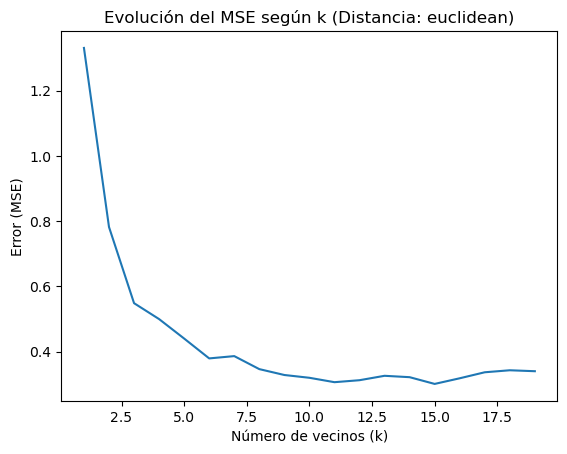


Evaluando con la distancia: manhattan
Cuando usamos k= 1 obtenemos 1.3176036718672113
Cuando usamos k= 2 obtenemos 0.8161815181624832
Cuando usamos k= 3 obtenemos 0.6268425780530025
Cuando usamos k= 4 obtenemos 0.5255604439923707
Cuando usamos k= 5 obtenemos 0.4911297725121801
Cuando usamos k= 6 obtenemos 0.49053884963140765
Cuando usamos k= 7 obtenemos 0.37554485414657357
Cuando usamos k= 8 obtenemos 0.36974189813123165
Cuando usamos k= 9 obtenemos 0.3629170984206455
Cuando usamos k= 10 obtenemos 0.3613993103668199
Cuando usamos k= 11 obtenemos 0.3302370785571312
Cuando usamos k= 12 obtenemos 0.3182305454034271
Cuando usamos k= 13 obtenemos 0.3515500750400256
Cuando usamos k= 14 obtenemos 0.36029179066549827
Cuando usamos k= 15 obtenemos 0.3722324582909256
Cuando usamos k= 16 obtenemos 0.3749845563038969
Cuando usamos k= 17 obtenemos 0.3857678796219952
Cuando usamos k= 18 obtenemos 0.3737879095018918
Cuando usamos k= 19 obtenemos 0.3776370964652818
Mejor resultado obtenido con la dis

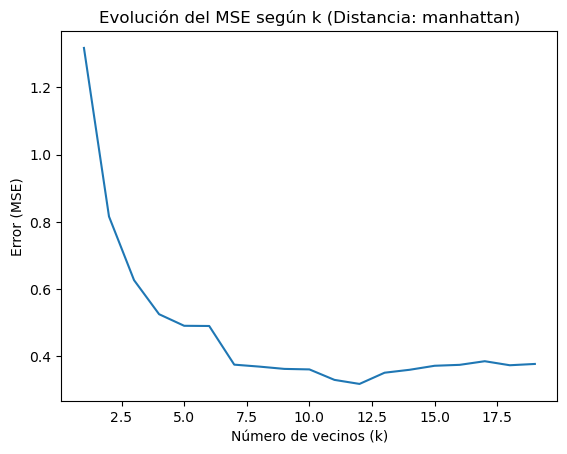


Evaluando con la distancia: cosine
Cuando usamos k= 1 obtenemos 0.9304208717556882
Cuando usamos k= 2 obtenemos 0.6261171612398141
Cuando usamos k= 3 obtenemos 0.47732945570669205
Cuando usamos k= 4 obtenemos 0.40458649801616253
Cuando usamos k= 5 obtenemos 0.4621365968563674
Cuando usamos k= 6 obtenemos 0.403712118693963
Cuando usamos k= 7 obtenemos 0.3952653977397218
Cuando usamos k= 8 obtenemos 0.3808891512923716
Cuando usamos k= 9 obtenemos 0.31255103500898723
Cuando usamos k= 10 obtenemos 0.32616973617659856
Cuando usamos k= 11 obtenemos 0.3083064202126754
Cuando usamos k= 12 obtenemos 0.3109251180951957
Cuando usamos k= 13 obtenemos 0.32784056337539236
Cuando usamos k= 14 obtenemos 0.3133440843750549
Cuando usamos k= 15 obtenemos 0.3311540375069676
Cuando usamos k= 16 obtenemos 0.3144368743522737
Cuando usamos k= 17 obtenemos 0.29473821943141704
Cuando usamos k= 18 obtenemos 0.2795292199779666
Cuando usamos k= 19 obtenemos 0.2781470052093677
Mejor resultado obtenido con la dista

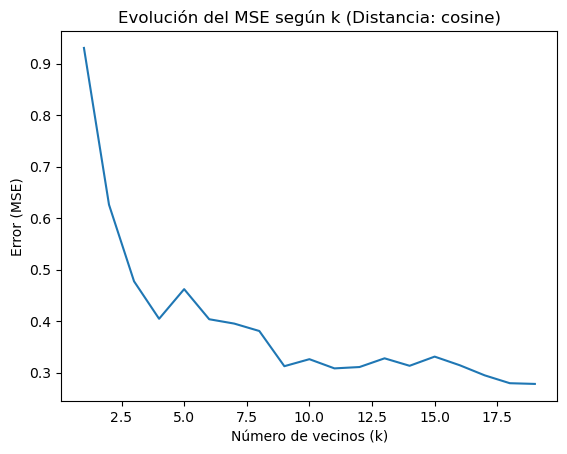


Evaluando con la distancia: jaccard
Cuando usamos k= 1 obtenemos 1.5716589323567642
Cuando usamos k= 2 obtenemos 0.9507851025581221
Cuando usamos k= 3 obtenemos 0.6997187142775757
Cuando usamos k= 4 obtenemos 0.6043519560381055
Cuando usamos k= 5 obtenemos 0.5975545846328404
Cuando usamos k= 6 obtenemos 0.6373974912943796
Cuando usamos k= 7 obtenemos 0.5560819921162661
Cuando usamos k= 8 obtenemos 0.5311062757163466
Cuando usamos k= 9 obtenemos 0.47280280150404247
Cuando usamos k= 10 obtenemos 0.48818087404472826
Cuando usamos k= 11 obtenemos 0.49609405863421047
Cuando usamos k= 12 obtenemos 0.4656516339719949
Cuando usamos k= 13 obtenemos 0.4749085271104521
Cuando usamos k= 14 obtenemos 0.49126649631123726
Cuando usamos k= 15 obtenemos 0.47995112434662435
Cuando usamos k= 16 obtenemos 0.4846890857484768
Cuando usamos k= 17 obtenemos 0.4903597071293971
Cuando usamos k= 18 obtenemos 0.48386229392250113
Cuando usamos k= 19 obtenemos 0.47827931464682905
Mejor resultado obtenido con la di

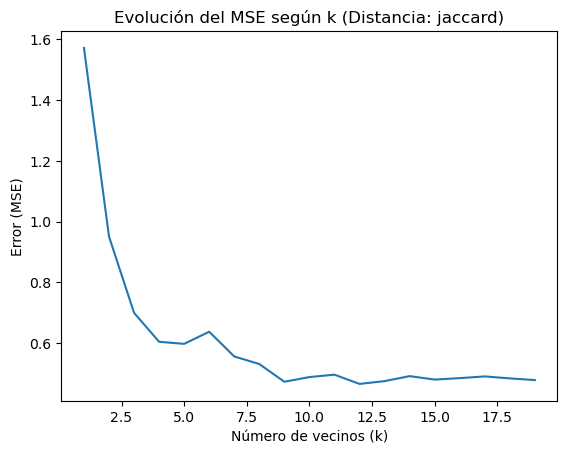


Evaluando con la distancia: chebyshev
Cuando usamos k= 1 obtenemos 0.7490730288402696
Cuando usamos k= 2 obtenemos 0.5109875283965738
Cuando usamos k= 3 obtenemos 0.4197519143592201
Cuando usamos k= 4 obtenemos 0.43394683552003405
Cuando usamos k= 5 obtenemos 0.38353096848182616
Cuando usamos k= 6 obtenemos 0.33776705511266064
Cuando usamos k= 7 obtenemos 0.3366604824010797
Cuando usamos k= 8 obtenemos 0.3324506243134312
Cuando usamos k= 9 obtenemos 0.3117896752680607
Cuando usamos k= 10 obtenemos 0.3157641104104676
Cuando usamos k= 11 obtenemos 0.2821620819525571
Cuando usamos k= 12 obtenemos 0.26386666744016185
Cuando usamos k= 13 obtenemos 0.26585181306786404
Cuando usamos k= 14 obtenemos 0.2711677220629435
Cuando usamos k= 15 obtenemos 0.2651002310580858
Cuando usamos k= 16 obtenemos 0.2721593785886793
Cuando usamos k= 17 obtenemos 0.25675158173357465
Cuando usamos k= 18 obtenemos 0.26955331410147293
Cuando usamos k= 19 obtenemos 0.26803572489249095
Mejor resultado obtenido con la

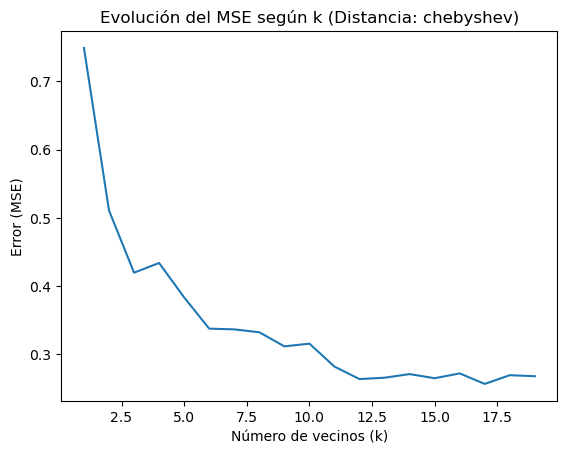


Evaluando con la distancia: minkowski
Cuando usamos k= 1 obtenemos 0.7545453507738273
Cuando usamos k= 2 obtenemos 0.778394237100257
Cuando usamos k= 3 obtenemos 0.5316313569713713
Cuando usamos k= 4 obtenemos 0.47491087292303413
Cuando usamos k= 5 obtenemos 0.3253284385458808
Cuando usamos k= 6 obtenemos 0.2909687163960545
Cuando usamos k= 7 obtenemos 0.2649486115339874
Cuando usamos k= 8 obtenemos 0.28775290672462744
Cuando usamos k= 9 obtenemos 0.2722512552920783
Cuando usamos k= 10 obtenemos 0.2647159754018167
Cuando usamos k= 11 obtenemos 0.2821412903584008
Cuando usamos k= 12 obtenemos 0.27745250429257906
Cuando usamos k= 13 obtenemos 0.299479643348118
Cuando usamos k= 14 obtenemos 0.29575922492530193
Cuando usamos k= 15 obtenemos 0.319732625985441
Cuando usamos k= 16 obtenemos 0.31669765399956473
Cuando usamos k= 17 obtenemos 0.3013659377276247
Cuando usamos k= 18 obtenemos 0.3028192119550114
Cuando usamos k= 19 obtenemos 0.29867014222171784
Mejor resultado obtenido con la dist

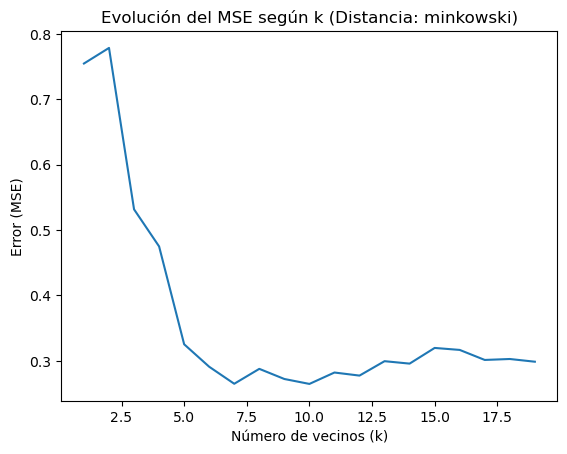

In [32]:
errores_por_distancia = evaluar_todas_las_distancias(usuario=usuario, lista_peliculas=lista_peliculas, valoraciones_peliculas=valoraciones_peliculas, min_vecinos=min_vecinos)

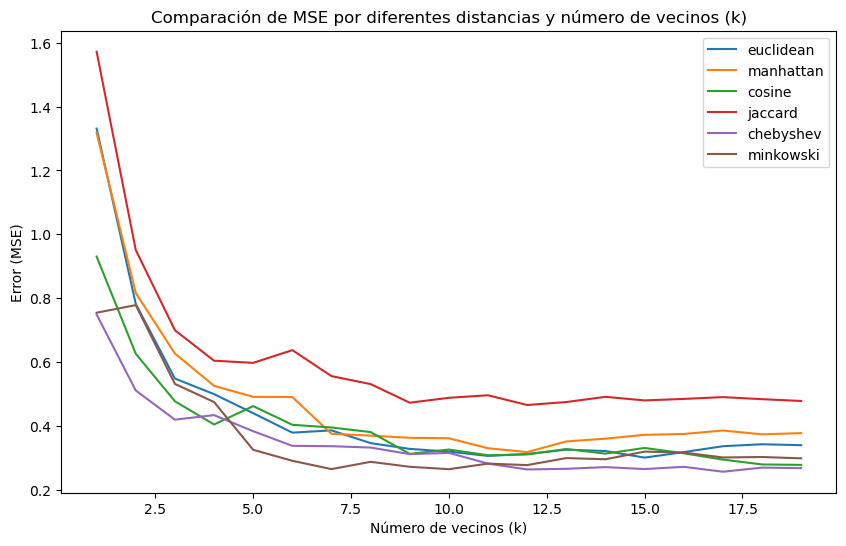

In [33]:
graficar_errores_por_distancia(errores_por_distancia=errores_por_distancia, min_vecinos=min_vecinos)

### Conclusión sobre la Elección de K Vecinos y Distancia

**La mejor distancia**:

1. **Chebyshev** y **Manhattan** muestran los valores de error más bajos en los primeros valores de \( k \). En el caso de Chebyshev, el menor MSE se obtiene con \( k=2 \) y un error de **1.0234**. Para Manhattan, el valor óptimo es \( k=3 \), con un MSE de **1.0961**. Esto sugiere que estas distancias son eficaces cuando solo se consideran unos pocos vecinos cercanos.

2. **Cosine** es una buena opción para trabajar con un número mayor de vecinos. El menor error para Cosine se obtiene con \( k=18 \) y un MSE de **1.1749**. Esto indica que Cosine puede capturar relaciones más profundas y complejas entre los ítems cuando se consideran más vecinos, lo que podría ser útil en escenarios donde el contexto adicional de varios usuarios mejora las recomendaciones.

**El valor de K**:

- **Para Euclidean, Manhattan, Chebyshev, y Minkowski**, el valor óptimo de \( k \) es generalmente bajo (\( k=2 \) o \( k=3 \)), lo que sugiere que un número pequeño de vecinos proporciona mejores predicciones en estos casos. Esto puede deberse a que los vecinos más cercanos son los más representativos de las preferencias del usuario.

- **Cosine** destaca al permitir un valor de \( k \) mayor (\( k=18 \)), lo que implica que en este caso agregar más vecinos mejora la calidad de las predicciones. Esto es útil en situaciones en las que el comportamiento de varios usuarios contribuye a captar patrones más complejos en las preferencias.

En resumen:

- Si buscamos el **menor error con pocos vecinos**, **Chebyshev** y **Manhattan** son buenas opciones.
- **Cosine** es preferible si queremos incluir más vecinos y obtener una recomendación que capture patrones generales.


En resumidas cuentas, nos quedaremos con la distancia de cosine porque nos interesa tener mas vecinos (aun asi ahora comprobaremos si es cierto que es la mejor)

### Ejecutar el codigo de cada algoritmo para las mejores K de cada algoritmo

Puesto que ya hemos valorado la mejor K, no hace falta limitar el calculo de similitud a las primeras 50 peliculas

In [59]:
usuario = 3
minimo_vecinos = 20

# Obtener lista de películas y valoraciones
lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, escasez)
lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
    lista_peliculas_usuario=lista_peliculas, 
    valoraciones_peliculas=valoraciones_peliculas, 
    matriz_normalizada=matriz_normalizada, 
    vecinos_min=minimo_vecinos
)

# Similitud Euclidean
similitud_euclideana = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='euclidean', 
    vecinos=2
)
print("Similitud Euclidean:", similitud_euclideana)

# Similitud Manhattan
similitud_manhattan = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='manhattan', 
    vecinos=3
)
print("Similitud Manhattan:", similitud_manhattan)

# Similitud Cosine
similitud_cosine = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='cosine', 
    vecinos=18
)
print("Similitud Cosine:", similitud_cosine)

# Similitud Jaccard
similitud_jaccard = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='jaccard', 
    vecinos=2
)
print("Similitud Jaccard:", similitud_jaccard)

# Similitud Chebyshev
similitud_chebyshev = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='chebyshev', 
    vecinos=2
)
print("Similitud Chebyshev:", similitud_chebyshev)

# Similitud Minkowski
similitud_minkowski = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='minkowski', 
    vecinos=2,
    minkowski=True
)
print("Similitud Minkowski:", similitud_minkowski)


Similitud Euclidean: [3.08, 0.74, 1.76, 0.5, 1.54, 3.21, 5.0, 1.09, 3.45, 5.0, 4.62, 0.5, 2.06, 3.63, 3.61, 2.67, 3.76, 3.47, 0.5, 4.58, 5.0, 1.43, 0.69, 2.29, 2.23, 2.16, 1.44, 5.0, 1.54, 1.98, 4.55, 3.41, 3.61, 3.76, 4.55, 4.28, 3.93, 3.12, 2.84, 4.99, 3.45, 2.73, 0.5, 1.22, 3.65, 0.8, 3.04, 4.41, 3.04, 1.74, 5.0, 2.57, 0.63, 1.97, 4.18, 3.46, 2.47, 2.23, 2.48, 4.07, 2.26, 3.47, 4.24, 3.97, 2.48, 3.43, 4.41, 3.74, 3.97, 1.25, 0.5, 3.82, 3.01, 2.84, 3.44, 1.36, 0.69, 1.75, 3.8, 0.5, 1.34, 3.37, 1.16, 2.55, 4.28, 3.74, 0.75, 0.5, 3.74, 3.33, 0.5, 3.11, 4.58, 2.04, 3.45, 0.5, 0.94, 1.55, 1.34, 3.03, 0.5, 3.93, 0.5, 3.33, 5.0, 0.5, 2.48, 1.09, 0.5, 3.91, 5.0, 2.78, 4.32, 3.0, 1.62, 0.5, 3.0, 2.42, 2.64, 1.6, 3.61, 1.35, 0.54, 0.91, 3.53, 2.33, 2.95, 3.78, 2.13, 0.5, 2.38, 4.26, 0.5, 3.85, 1.83, 0.94, 1.03, 3.47]
Similitud Manhattan: [2.81, 1.25, 1.92, 1.73, 2.26, 3.74, 5.0, 1.91, 3.57, 5.0, 4.04, 1.2, 2.39, 3.16, 3.65, 2.87, 3.6, 2.26, 0.59, 4.02, 4.44, 1.07, 1.69, 3.11, 3.42, 5.0, 2.12,

Ahora vamos a comparar cada una de las distancias con las valoraciones originales

In [ ]:
def graficar_similitudes(valoraciones_peliculas, similitudes_dict, limit=25):
    plt.figure(figsize=(10, 6))
    # Graficar las valoraciones originales (limitadas a las primeras `limit` películas)
    plt.plot(valoraciones_peliculas[:limit], label="Valoraciones Originales", marker='o', linestyle='-', color='black')
    # Graficar las similitudes de cada distancia (limitadas a las primeras `limit` películas)
    for distancia, similitudes in similitudes_dict.items():
        plt.plot(similitudes[:limit], label=f"Similitud {distancia}", marker='o', linestyle='--')

    plt.xlabel('Películas')
    plt.ylabel('Valoración')
    plt.title(f'Similitudes por Distancia (Primeras {limit} Películas)')
    plt.legend()
    plt.show()

def calcular_mejor_distancia_global(valoraciones_peliculas, similitudes_dict):
    errores_totales = {}

    # Calcular el error total para cada distancia
    for distancia, similitudes in similitudes_dict.items():
        error_total = sum(abs(valoracion - similitudes[idx]) for idx, valoracion in enumerate(valoraciones_peliculas))
        errores_totales[distancia] = error_total

    # Seleccionar la distancia con el menor error total
    mejor_distancia_global = min(errores_totales, key=errores_totales.get)
    
    return mejor_distancia_global, errores_totales

def calcular_accuracy_promedio_por_distancia(valoraciones_peliculas, similitudes_dict):
    accuracies_porcentaje = {}

    # Calcular el accuracy promedio para cada distancia
    for distancia, similitudes in similitudes_dict.items():
        accuracies_individuales = []
        
        for valoracion, prediccion in zip(valoraciones_peliculas, similitudes):
            if valoracion != 0:  # Evitar divisiones por cero
                accuracy_individual = 1 - abs(valoracion - prediccion) / valoracion
                accuracies_individuales.append(accuracy_individual)
        
        # Calcular el promedio de los accuracies individuales para esta distancia
        accuracy_promedio = (sum(accuracies_individuales) / len(accuracies_individuales)) * 100 if accuracies_individuales else 0
        accuracies_porcentaje[distancia] = accuracy_promedio

    # Seleccionar la distancia con el mayor accuracy promedio
    mejor_distancia_global = max(accuracies_porcentaje, key=accuracies_porcentaje.get)

    # Comparar el accuracy promedio de cada distancia con el mejor (al final no lo uso)
    comparacion_accuracies = {}
    mejor_accuracy = accuracies_porcentaje[mejor_distancia_global]

    for distancia, accuracy in accuracies_porcentaje.items():
        comparacion_accuracies[distancia] = {
            "accuracy_promedio": accuracy,
            "comparado_con_mejor": (accuracy / mejor_accuracy) * 100
        }

    return mejor_distancia_global, comparacion_accuracies


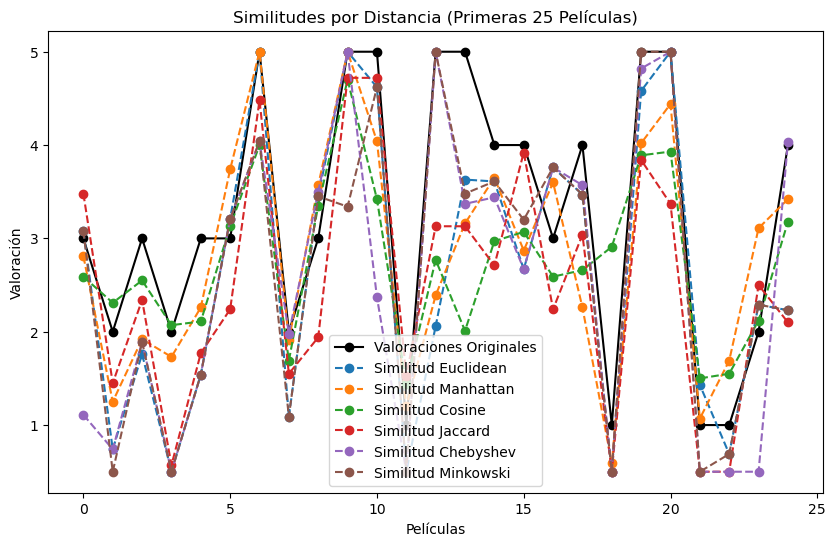

In [ ]:
similitudes_dict = {
    "Euclidean": similitud_euclideana,
    "Manhattan": similitud_manhattan,
    "Cosine": similitud_cosine,
    "Jaccard": similitud_jaccard,
    "Chebyshev": similitud_chebyshev,
    "Minkowski": similitud_minkowski
}
graficar_similitudes(valoraciones_peliculas, similitudes_dict,limit=25)

In [ ]:
mejor_distancia_global, comparacion_errores = calcular_accuracy_promedio_por_distancia(valoraciones_peliculas, similitudes_dict)

print(f"La mejor distancia global es {mejor_distancia_global}")
for distancia, datos in comparacion_errores.items():
    print(f"Distancia: {distancia}")
    print(f"  Accuracy Promedio: {datos['accuracy_promedio']:.2f}%")


La mejor distancia global es Chebyshev
Distancia: Euclidean
  Accuracy Promedio: 68.76%
Distancia: Manhattan
  Accuracy Promedio: 64.46%
Distancia: Cosine
  Accuracy Promedio: 66.66%
Distancia: Jaccard
  Accuracy Promedio: 70.42%
Distancia: Chebyshev
  Accuracy Promedio: 71.24%
Distancia: Minkowski
  Accuracy Promedio: 69.42%


# ` Análisis de la Mejor Distancia para Recomendación`

**Distancia Globalmente Óptima**:  
La distancia **Chebyshev** ofrece el mayor accuracy promedio, con un **71.24%**, y es la mejor opción global cuando buscamos la mayor precisión en relación a las valoraciones originales. En este análisis, se usó un valor de \( k = 2 \) vecinos.

**Comparación de Distancias**:

- **Jaccard**, también evaluada con \( k = 2 \), obtuvo un accuracy cercano del **70.42%**, lo que la hace una opción competitiva. 
- **Cosine** mostró un buen desempeño con **66.66%** de accuracy promedio, usando \( k = 18 \), lo cual resalta su capacidad de capturar relaciones complejas en configuraciones con más vecinos.

**Elección del Valor de \( k \) y la Distancia**:

- Para un **número reducido de vecinos** (bajo \( k \)), **Chebyshev** es la elección óptima para minimizar el error.
- Para un **número mayor de vecinos** (como \( k = 18 \)), **Cosine** es preferible ya que puede capturar relaciones complejas entre ítems, reflejando contextos amplios en las recomendaciones.

En conclusión, la elección entre Chebyshev y Cosine depende del valor de \( k \):  

- **Chebyshev** ` es óptima con pocos vecinos.  `
- **Cosine** ` es ideal para una cantidad de vecinos altos, donde se beneficie de más contexto en los datos.`

`En este caso nos decantaremos por la distancia de Cosine, ya que nos interesa sobre todo una mayor K y poder capturar relaciones amplias en las recomendaciones.`

**Resultados por Distancia:**

- Distancia **Euclidean** (vecinos = 2): Accuracy Promedio de **68.76%**
- Distancia **Manhattan** (vecinos = 3): Accuracy Promedio de **64.46%**
- Distancia **Cosine** (vecinos = 18): Accuracy Promedio de **66.66%**
- Distancia **Jaccard** (vecinos = 2): Accuracy Promedio de **70.42%**
- Distancia **Chebyshev** (vecinos = 2): Accuracy Promedio de **71.24%**
- Distancia **Minkowski** (vecinos = 2): Accuracy Promedio de **69.42%**



## 6. Accuracy Promedio

In [ ]:
def calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitudes):
    # Calcular la precisión individual para cada valoración
    accuracies_individuales = [1 - abs(valoracion - prediccion) / valoracion if valoracion != 0 else 0
        for valoracion, prediccion in zip(valoraciones_peliculas, similitudes)
    ]
    
    accuracy_promedio = sum(accuracies_individuales) / len(accuracies_individuales) * 100 if accuracies_individuales else 0
    
    return accuracy_promedio


In [75]:
def total_accuracy(n_usuarios):
    minimo_vecinos = 20
    mejores_vecinos = 18
    lista_usuarios = list(df['userId'].unique())[0:(n_usuarios-1)]
    usuarios_vistos = 0
    sum_accuracys = 0 
    for usuario in lista_usuarios:
        print("Usuario nº: " + str(usuario))
        usuarios_vistos += 1
        lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, escasez)
        lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
            lista_peliculas_usuario=lista_peliculas, 
            valoraciones_peliculas=valoraciones_peliculas, 
            matriz_normalizada=matriz_normalizada, 
            vecinos_min=minimo_vecinos
        )
        similitud_cosine = similitud_distancias(
            lista_peliculas_usuario=lista_peliculas, 
            usuario=usuario, 
            distancia_escogida='cosine', 
            vecinos=mejores_vecinos
        )
        
        accuracy_promedio = calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitud_cosine) # Calcular accuracy promedio como un valor escalar
        sum_accuracys += accuracy_promedio  

    print(f"Accuracy promedio: {sum_accuracys / usuarios_vistos:.2f}%")


n_usuarios = 610
total_accuracy(n_usuarios = n_usuarios)




Usuario nº: 1
Usuario nº: 2
Usuario nº: 3
Usuario nº: 4
Usuario nº: 5
Usuario nº: 6
Usuario nº: 7
Usuario nº: 8
Usuario nº: 9
Usuario nº: 10
Usuario nº: 11
Usuario nº: 12
Usuario nº: 13
Usuario nº: 14
Usuario nº: 15
Usuario nº: 16
Usuario nº: 17
Usuario nº: 18
Usuario nº: 19
Usuario nº: 20
Usuario nº: 21
Usuario nº: 22
Usuario nº: 23
Usuario nº: 24
Usuario nº: 25
Usuario nº: 26
Usuario nº: 27
Usuario nº: 28
Usuario nº: 29
Usuario nº: 30
Usuario nº: 31
Usuario nº: 32
Usuario nº: 33
Usuario nº: 34
Usuario nº: 35
Usuario nº: 36
Usuario nº: 37
Usuario nº: 38
Usuario nº: 39
Usuario nº: 40
Usuario nº: 41
Usuario nº: 42
Usuario nº: 43
Usuario nº: 44
Usuario nº: 45
Usuario nº: 46
Usuario nº: 47
Usuario nº: 48
Usuario nº: 49
Usuario nº: 50
Usuario nº: 51
Usuario nº: 52
Usuario nº: 53
Usuario nº: 54
Usuario nº: 55
Usuario nº: 56
Usuario nº: 57
Usuario nº: 58
Usuario nº: 59
Usuario nº: 60
Usuario nº: 61
Usuario nº: 62
Usuario nº: 63
Usuario nº: 64
Usuario nº: 65
Usuario nº: 66
Usuario nº: 67
Usua

## 7. Predicciones

Ahora que ya sabemos que distancia y que K nos corresponde podemos hacer la prediccion para el usuario que deseemos, esta predicción nos devolverá las 10 mejores predicciones del usuario, las cuales se le recomendarían

In [ ]:
import pandas as pd

# Cargar los archivos CSV proporcionados
movies = pd.read_csv('BBDD_100K/movies.csv')
ratings = pd.read_csv('BBDD_100K/ratings.csv')

# Mostrar una muestra de los datos para asegurarnos de que se han cargado correctamente
print(movies.head())
print(ratings.head())


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

def peliculas_no_valoradas(usuario, matriz_escasez):    
    peliculas_no_votadas = matriz_escasez.loc[usuario][matriz_escasez.loc[usuario].isna()].index.tolist() # Filtrar las películas que el usuario no ha valorado (NaN en la matriz de escasez)
    
    return peliculas_no_votadas

def peliculas_con_minimo_vecinos(lista_peliculas_usuario, usuario_pelicula, vecinos_min):
    # Filtramos solo las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_filtradas = []

    for pelicula in lista_peliculas_usuario:
        # Asegurarse de que 'pelicula' es el identificador correcto que corresponde a las columnas de usuario_pelicula
        if pelicula not in usuario_pelicula.columns:
            continue
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)][pelicula]  # Seleccionamos los usuarios que vieron la película
        
        # Si el número de usuarios que vieron la película es mayor o igual a 'vecinos_min', la añadimos a la lista
        if len(usuarios_que_vieron_la_pelicula) >= vecinos_min:
            peliculas_filtradas.append(pelicula)

    return peliculas_filtradas

def reescalar_prediccion(prediccion_normalizada, id_usuario, matriz_escasez_original, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_escasez_original.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_escasez_original.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        prediccion_reescalada = np.clip(round(prediccion_reescalada, 2), min_rating, max_rating) # Clipping para mantener la predicción dentro del rango y redondeo
    else:
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

def recomendar_peliculas(usuario, escasez, usuario_pelicula, movies,mejores_vecinos, distancia_escogida='manhattan', vecinos=20, top_n=10, limite_peliculas_no_votadas=100):
   
    # Obtener las películas que el usuario no ha valorado
    peliculas_no_votadas = peliculas_no_valoradas(usuario, escasez)
    
    # Limitar el número de películas no votadas que vamos a evaluar
    if len(peliculas_no_votadas) > limite_peliculas_no_votadas:
        peliculas_no_votadas = np.random.choice(peliculas_no_votadas, limite_peliculas_no_votadas, replace=False)
    
    # Filtrar las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_no_votadas = peliculas_con_minimo_vecinos(peliculas_no_votadas, usuario_pelicula, vecinos_min=vecinos)
    
    # Predecir las valoraciones para las películas no votadas
    predicciones = []
    for pelicula in peliculas_no_votadas:
        # Seleccionamos los usuarios que han valorado la película
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)]
        
        if usuarios_que_vieron_la_pelicula.empty:
            continue  # Saltar si no hay usuarios con valoraciones para esta película
        
        # Datos del usuario objetivo para la predicción
        usuario_objetivo = usuario_pelicula.iloc[[usuario]]

        # Reemplazar NaNs con ceros en los datos de entrada para evitar errores
        usuarios_que_vieron_la_pelicula = usuarios_que_vieron_la_pelicula.fillna(0)
        usuario_objetivo = usuario_objetivo.fillna(0)

        # Modelo KNN para la predicción
        knn = KNeighborsRegressor(metric=distancia_escogida, n_neighbors=mejores_vecinos)
        knn.fit(usuarios_que_vieron_la_pelicula, usuario_pelicula.loc[usuarios_que_vieron_la_pelicula.index, pelicula])
        
        # Predecir la valoración del usuario para la película
        prediccion_usuario = knn.predict(usuario_objetivo)[0]
        prediccion_reescalada = reescalar_prediccion(prediccion_usuario, usuario, escasez)
        
        # Guardar la predicción con el ID de la película
        predicciones.append((pelicula, prediccion_reescalada))
    
    # Ordenar las predicciones por valoración en orden descendente
    predicciones.sort(key=lambda x: x[1], reverse=True)
    
    # Seleccionar las top_n mejores películas
    mejores_peliculas = predicciones[:top_n]
    
    # Obtener los nombres de las mejores películas
    recomendaciones = pd.DataFrame(mejores_peliculas, columns=['movieId', 'Predicted Rating']).merge(movies, on='movieId')
    
    return recomendaciones[['title', 'Predicted Rating', 'genres']]


In [ ]:
usuario_id = 6
mejores_vecinos_cosine = 18
min_vecinos = 20

In [ ]:
recomendaciones = recomendar_peliculas(usuario_id, escasez, matriz_normalizada, movies,mejores_vecinos_cosine, distancia_escogida='cosine', vecinos=min_vecinos, top_n=10)

recomendaciones.head(10)

,title,Predicted Rating,genres
0,Labyrinth (1986),4.12,Adventure|Fantasy|Musical
1,To Catch a Thief (1955),4.07,Crime|Mystery|Romance|Thriller
2,Before Sunrise (1995),3.89,Drama|Romance
3,"Simple Plan, A (1998)",3.79,Crime|Drama|Thriller
4,"Few Good Men, A (1992)",3.73,Crime|Drama|Thriller
5,The Hunger Games: Catching Fire (2013),3.67,Action|Adventure|Sci-Fi|IMAX
6,From Hell (2001),3.60,Crime|Horror|Mystery|Thriller
7,"Amazing Spider-Man, The (2012)",3.40,Action|Adventure|Sci-Fi|IMAX
8,Road Trip (2000),3.19,Comedy
9,Signs (2002),2.93,Horror|Sci-Fi|Thriller


Tambien podemos buscar al usuario con la media de valoraciones mas baja posible, para ver si las predicciones se hacen entorno a esos valores.

En el siguiente ejemplo podemos ver como el usuario 442 tiene una media de 1.275, y las valoraciones se hacen entorno a esos datos

In [ ]:
# Encontrar al usuario con la media de valoraciones más baja
def usuario_media_mas_baja(matriz_escasez):
    # Calcular la media de valoraciones de cada usuario, ignorando los NaN
    medias_usuarios = matriz_escasez.mean(axis=1, skipna=True)
    
    # Encontrar el usuario con la media más baja
    usuario_min_media = medias_usuarios.idxmin()
    media_min = medias_usuarios.min()
    
    print(f"Usuario con la media más baja: {usuario_min_media}")
    print(f"Media de valoraciones del usuario: {media_min}")
    
    return usuario_min_media

# Ejemplo de ejecución para encontrar al usuario con la media más baja
usuario_con_media_baja = usuario_media_mas_baja(escasez)


Usuario con la media más baja: 442
Media de valoraciones del usuario: 1.275


In [ ]:
usuario_id = 442
recomendaciones = recomendar_peliculas(usuario_id, escasez, matriz_normalizada, movies,mejores_vecinos_cosine, distancia_escogida='cosine', vecinos=min_vecinos, top_n=10)

recomendaciones.head(10)

,title,Predicted Rating,genres
0,Office Space (1999),1.61,Comedy|Crime
1,Major League (1989),1.35,Comedy
2,Fried Green Tomatoes (1991),1.32,Comedy|Crime|Drama
3,Grumpy Old Men (1993),1.25,Comedy
4,Billy Madison (1995),1.24,Comedy
5,300 (2007),1.20,Action|Fantasy|War|IMAX
6,Groundhog Day (1993),1.16,Comedy|Fantasy|Romance
7,Sister Act (1992),0.97,Comedy|Crime
8,My Big Fat Greek Wedding (2002),0.91,Comedy|Romance


También podemos ver que usuario es el que mas se parece a otro usuario, esto lo haremos con el coeficiente de pearson

In [ ]:
usuario_id = 3
def usuario_mas_similar(usuario_id, escasez, min_peliculas_comunes=5):
    # Extraer las valoraciones del usuario objetivo
    valoraciones_usuario = escasez.loc[usuario_id]
    
    # Calcular la correlación de Pearson entre el usuario objetivo y todos los demás usuarios
    correlaciones = escasez.corrwith(valoraciones_usuario, axis=1, method='pearson')
    
    # Eliminar la correlación del usuario consigo mismo
    correlaciones = correlaciones.drop(index=usuario_id)
    
    # Filtrar usuarios con pocas valoraciones en común
    peliculas_comunes = escasez.notna().multiply(valoraciones_usuario.notna(), axis=0).sum(axis=1)
    correlaciones = correlaciones[peliculas_comunes >= min_peliculas_comunes]
    
    # Eliminar usuarios con una correlación de 1 (idénticas valoraciones)
    correlaciones = correlaciones[correlaciones < 1]
    
    # Encontrar el usuario con la mayor correlación positiva
    usuario_mas_similar = correlaciones.idxmax()
    coeficiente_correlacion = correlaciones.max()
    
    return usuario_mas_similar, coeficiente_correlacion

# Ejemplo de uso
usuario_similar, correlacion = usuario_mas_similar(usuario_id, escasez)
print(f"El usuario más similar al usuario {usuario_id} es {usuario_similar} con un coeficiente de correlación de Pearson de {correlacion:.2f}.")



El usuario más similar al usuario 3 es 527 con un coeficiente de correlación de Pearson de 0.68.
